In [1]:
import pandas as pd
import numpy as np

In [2]:
movie_df = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/movies_clean.csv")
links_df = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/links_clean.csv")
ratings_df = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/ratingss_clean.csv")

In [56]:
movie_df.head()

,movieId,title,genres,year,genre_list,avg_rating,rating_count,popularity_score,decade,movie_age,genre_count,popularity_level,weighted_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,"[Adventure, Animation, Children, Comedy, Fantasy]",3.897438,68997.0,268911.5,1990.0,31.0,5,most_popular,3.894113
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,"[Adventure, Children, Fantasy]",3.275758,28904.0,94682.5,1990.0,31.0,3,most_popular,3.272767
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,"[Comedy, Romance]",3.139447,13134.0,41233.5,1990.0,31.0,2,most_popular,3.135273
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,"[Comedy, Drama, Romance]",2.845331,2806.0,7984.0,1990.0,31.0,3,most_popular,2.849238
4,5,Father of the Bride Part II (1995),Comedy,1995.0,[Comedy],3.059602,13154.0,40246.0,1990.0,31.0,1,most_popular,3.056806


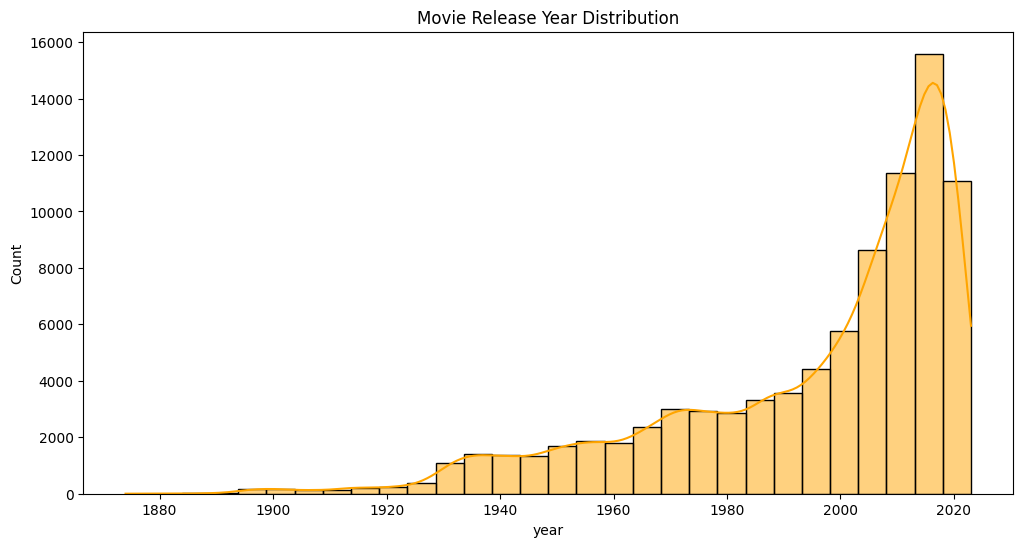

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(
    movie_df["year"],
    bins=30,
    kde=True,
    color = "orange"
)

plt.title("Movie Release Year Distribution")
plt.show()

In [5]:
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   movieId           87585 non-null  int64  
 1   title             87585 non-null  object 
 2   genres            87585 non-null  object 
 3   year              86970 non-null  float64
 4   genre_list        87585 non-null  object 
 5   avg_rating        84432 non-null  float64
 6   rating_count      84432 non-null  float64
 7   popularity_score  84432 non-null  float64
 8   decade            86970 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 6.0+ MB


In [6]:
movie_df["avg_rating"] = movie_df["avg_rating"].fillna(0)

movie_df["rating_count"] = movie_df["rating_count"].fillna(0)

movie_df["popularity_score"] = movie_df["popularity_score"].fillna(0)

movie_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   movieId           87585 non-null  int64  
 1   title             87585 non-null  object 
 2   genres            87585 non-null  object 
 3   year              86970 non-null  float64
 4   genre_list        87585 non-null  object 
 5   avg_rating        87585 non-null  float64
 6   rating_count      87585 non-null  float64
 7   popularity_score  87585 non-null  float64
 8   decade            86970 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 6.0+ MB


In [7]:
movie_df["year"] = movie_df["year"].fillna(
    movie_df["year"].median()
)
movie_df["decade"] = (
    movie_df["year"] // 10
) * 10
movie_df.isnull().sum()


movieId             0
title               0
genres              0
year                0
genre_list          0
avg_rating          0
rating_count        0
popularity_score    0
decade              0
dtype: int64

In [57]:
movie_df.to_csv(
    "/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/artifacts/movies_features.csv",
    index=False
)

In [9]:
from datetime import datetime

current_year = datetime.now().year

movie_df["movie_age"] = (
    current_year -
    movie_df["year"]
)

movie_df[
    ["title","year","movie_age"]
].head()

movie_df["movie_age"].describe()

count    87585.000000
mean        30.571022
std         25.934844
min          3.000000
25%         11.000000
50%         20.000000
75%         45.000000
max        152.000000
Name: movie_age, dtype: float64

In [10]:
movie_df.to_csv(
    "/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/artifacts/movies_features.csv",
    index=False
)


In [47]:

movie_df[["title","genre_list","genre_count"]].head()


,title,genre_list,genre_count
0,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",5
1,Jumanji (1995),"[Adventure, Children, Fantasy]",3
2,Grumpier Old Men (1995),"[Comedy, Romance]",2
3,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",3
4,Father of the Bride Part II (1995),[Comedy],1


In [46]:
print(movie_df["genre_list"].iloc[0])

print(type(movie_df["genre_list"].iloc[0]))

print(len(movie_df["genre_list"].iloc[0]))
movie_df["genre_count"] = movie_df["genre_list"].apply(len)
movie_df["genre_count"] = movie_df["genre_list"].apply(len)
movie_df[["title", "genre_list", "genre_count"]].head()


['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']
<class 'list'>
5


,title,genre_list,genre_count
0,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",5
1,Jumanji (1995),"[Adventure, Children, Fantasy]",3
2,Grumpier Old Men (1995),"[Comedy, Romance]",2
3,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",3
4,Father of the Bride Part II (1995),[Comedy],1


In [16]:
movie_df["popularity_level"] = pd.qcut(
    movie_df["rating_count"],
    q=4,
    labels=[
        "low_popular",
        "medium_popular",
        "high_popular",
        "most_popular"
    ]
)

movie_df[["title", "rating_count", "popularity_level"]].head()
movie_df["popularity_level"].value_counts()

popularity_level
low_popular       32165
most_popular      21609
high_popular      18796
medium_popular    15015
Name: count, dtype: int64

In [54]:
C = movie_df["avg_rating"].mean()

m = movie_df["rating_count"].quantile(0.90)

movie_df["weighted_rating"] = (
    (
        movie_df["rating_count"] /
        (movie_df["rating_count"] + m)
    ) * movie_df["avg_rating"]
    +
    (
        m /
        (movie_df["rating_count"] + m)
    ) * C
)
movie_df.head()

,movieId,title,genres,year,genre_list,avg_rating,rating_count,popularity_score,decade,movie_age,genre_count,popularity_level,weighted_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,"[Adventure, Animation, Children, Comedy, Fantasy]",3.897438,68997.0,268911.5,1990.0,31.0,5,most_popular,3.894113
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,"[Adventure, Children, Fantasy]",3.275758,28904.0,94682.5,1990.0,31.0,3,most_popular,3.272767
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,"[Comedy, Romance]",3.139447,13134.0,41233.5,1990.0,31.0,2,most_popular,3.135273
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,"[Comedy, Drama, Romance]",2.845331,2806.0,7984.0,1990.0,31.0,3,most_popular,2.849238
4,5,Father of the Bride Part II (1995),Comedy,1995.0,[Comedy],3.059602,13154.0,40246.0,1990.0,31.0,1,most_popular,3.056806


In [55]:
movie_df[
    movie_df["rating_count"] < 5
][
    ["title","avg_rating","rating_count","weighted_rating"]
].head(20)

,title,avg_rating,rating_count,weighted_rating
1759,Ratchet (1996),2.500000,2.0,2.893480
3141,Train Ride to Hollywood (1975),3.333333,3.0,2.902521
3197,Soft Toilet Seats (1999),2.333333,3.0,2.889645
3263,Condo Painting (2000),3.000000,1.0,2.897348
3463,Stacy's Knights (1982),1.000000,1.0,2.888690
3484,"Jails, Hospitals & Hip-Hop (2000)",2.166667,3.0,2.887499
3650,Boricua's Bond (2000),1.750000,4.0,2.877296
3968,Dog Run (1996),2.000000,4.0,2.881570
4657,Djomeh (2000),2.750000,4.0,2.894390
4715,Won't Anybody Listen? (2000),1.500000,3.0,2.878916
